# Load data

In [1]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

print(f"Pytorch version: {torch.__version__}\nTorchvision version: {torchvision.__version__}")


Pytorch version: 2.12.0+cpu
Torchvision version: 0.27.0+cpu


# Prepare data

## Download Fashion MNIST data

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root                = "data",
    train               = True,
    download            = True,
    transform           = ToTensor(),
    target_transform    = None
)

# Setup test data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


## Inspect information from data

In [3]:
# See first training sample
image, label = train_data[0]
image, label
# shape of the image
print(f"Shape of trained image: {image.shape}")
# How many sample are there
print(f"Number trained data: {len(train_data.data)}")
print(f"Number of test data: {test_data.data}")

Shape of trained image: torch.Size([1, 28, 28])
Number trained data: 60000
Number of test data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ...

In [4]:
# See the class names
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Visualize data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

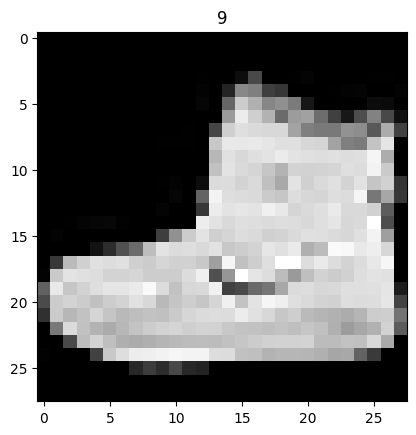

In [5]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(label)

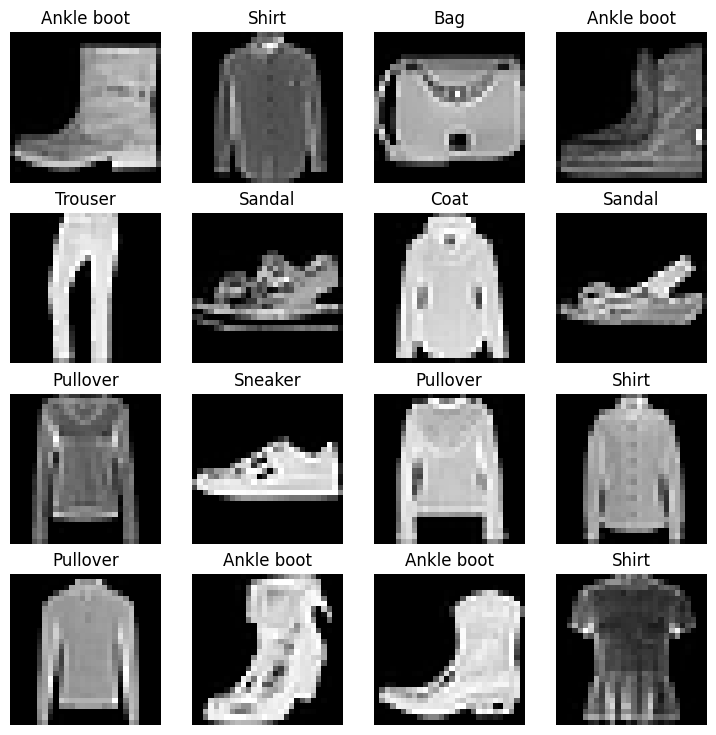

In [6]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

## Prepare data loader

In [8]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data, 
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
# Check how many batches created
print(f"Number of trained batches: {len(train_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

Number of trained batches: 1875
Number of test batches: 313


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


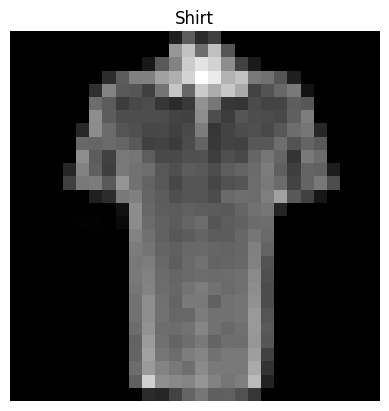

In [11]:
# Checking single sample in batch
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=([1])).item()
img = train_features_batch[random_idx]
label = train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off")
print(f"Image shape: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

# Build a baseline model

In [12]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Test flatten layer
x = train_features_batch[0]
output = flatten_model(x)

print(f"Shape of image before flatten: {x.shape}")
print(f"Shape of image after flatten: {output.shape}")

Shape of image before flatten: torch.Size([1, 28, 28])
Shape of image after flatten: torch.Size([1, 784])


In [13]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.Linear(hidden_units, output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [14]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names))
model_0.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [15]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

## Setup loss function and optimizer

In [16]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [17]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [19]:
from tqdm.auto import tqdm
torch.manual_seed(42)
train_time_start_on_cpu = timer()
epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------------------------")
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # Forward pass
        y_pred = model_0(X)
        # Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        # Optimizer zero grade
        optimizer.zero_grad()
        # Loss backward
        loss.backward()        
        # Optimizer step
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    test_loss = 0
    test_acc = 0
    model_0.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:
            # Forward pass
            test_pred = model_0(X)
            # Calculate loss
            test_loss += loss_fn(test_pred, y)
            # Calculate accuracy
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 10%|█         | 1/10 [00:04<00:43,  4.85s/it]


Train loss: 1106.97998 | Test loss: 0.51016, Test acc: 82.04%

Epoch: 1
---------------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 20%|██        | 2/10 [00:09<00:38,  4.84s/it]

...


Train loss: 792.61383 | Test loss: 0.48642, Test acc: 83.02%

Epoch: 8
---------------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 90%|█████████ | 9/10 [00:45<00:05,  5.10s/it]


Train loss: 788.08124 | Test loss: 0.44760, Test acc: 84.10%

Epoch: 9
---------------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 10/10 [00:50<00:00,  5.06s/it]


Train loss: 780.60107 | Test loss: 0.46222, Test acc: 83.86%

Train time on cpu: 50.582 seconds


# Make prediction from baseline model

In [20]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_accuracy": acc}

model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.462065726518631,
 'model_accuracy': 83.86581469648563}

# Setup device agnostic code for future model


# Adding non-linearity

In [21]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.stack_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, output_shape),
            nn.ReLU()
        )
    def forward(self, X: torch.Tensor):
        return self.stack_layer(X)


In [22]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(class_names))


In [23]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [35]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn):
    train_loss, train_acc = 0, 0
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        # 1. Forward pass
        y_pred = model(X)
        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc  += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        # 3. Optimizer zero grad
        optimizer.zero_grad()
        # 4. Loss backward
        loss.backward()
        # 5. Optimizer step
        optimizer.step()
        # Print progress of batches iterations
        if (batch % 500 == 0):
            print(f"Passed {batch}/{len(data_loader)} train batches")
        

    # Normalize loss and accuracy
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"==> Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.5f}")

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn):
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(data_loader):
            # 1. forward pass
            test_pred = model(X)
            # 2. Calculate loss & accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc  += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
            if (batch % 500 == 0):
                print(f"Passed {batch}/{len(data_loader)} test batches")
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

    print(f"==> Test loss: {test_loss:.5f} | Train loss: {test_acc:.5f}")

def train_loop(model, train_dataloader, test_dataloader, loss_fn, optimizer, accuracy_fn, epochs=100):
    for epoch in range(epochs):
        print(f"Epoch [{epoch} / {epochs}] -------------")
        # 1. Train step
        train_step(model=model, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)
        # 2. Test step
        test_step(model=model, data_loader=test_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

In [34]:
# Train model V1
train_loop(model_1, train_dataloader, test_dataloader, loss_fn, optimizer, accuracy_fn, 10)

Epoch [0 / 10] -------------
Passed 0/1875 batches
Passed 500/1875 batches
Passed 1000/1875 batches
Passed 1500/1875 batches
==> Train loss: 0.38287 | Train accuracy: 86.28667
Passed 0/313 batches
==> Test loss: 0.42938 | Train loss: 84.67452
Epoch [1 / 10] -------------
Passed 0/1875 batches
Passed 500/1875 batches
Passed 1000/1875 batches
Passed 1500/1875 batches
==> Train loss: 0.37752 | Train accuracy: 86.46333
Passed 0/313 batches
==> Test loss: 0.44644 | Train loss: 83.85583
Epoch [2 / 10] -------------
Passed 0/1875 batches
Passed 500/1875 batches
Passed 1000/1875 batches
Passed 1500/1875 batches
==> Train loss: 0.37648 | Train accuracy: 86.59167
Passed 0/313 batches
==> Test loss: 0.45204 | Train loss: 83.77596
Epoch [3 / 10] -------------
Passed 0/1875 batches
Passed 500/1875 batches
Passed 1000/1875 batches
Passed 1500/1875 batches
==> Train loss: 0.37410 | Train accuracy: 86.60333
Passed 0/313 batches
==> Test loss: 0.42203 | Train loss: 84.86422
Epoch [4 / 10] -------------

In [38]:
# Evaluate model version 1
torch.manual_seed(42)
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_1_results


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.44710206985473633,
 'model_accuracy': 83.97563897763578}

In [39]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.462065726518631,
 'model_accuracy': 83.86581469648563}

# CNN

In [ ]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units*7*7, output_shape)
        )
    def forward()

# Evaluate our best model

# Save the best model